In [2]:
# 02_retention_cohort
#
# 목적: transactions.csv를 DuckDB SQL로 집계해 (1) 유저별 첫 결제월 기준 코호트 리텐션 매트릭스,
#      (2) 전체 평균 리텐션 곡선을 만든다.
#
# 정의: 유저의 "활동"은 해당 월에 거래(transaction)가 1건 이상 있는 것으로 정의한다
#      (구독 상태를 날짜 구간으로 정교하게 추적하는 대신, 단순하고 해석하기 쉬운 정의 채택).
# 데이터 범위: 2015-01 ~ 2017-02 (transactions.csv 전체 히스토리) — 2015~2017년 스냅샷 기준 분석이며
#      "최근" 트렌드가 아니라 역사적 데이터 기반 분석임에 유의.
#
# 입력: data/raw/transactions.csv
# 출력: 시각화만 (별도 파일 저장 없음)

In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

RAW_DIR = Path("../data/raw")
con = duckdb.connect()

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
SERIES_1 = "#2a78d6"
BLUE_SEQ_CMAP = LinearSegmentedColormap.from_list(
    "series1_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
)

In [4]:
cohort_raw = con.sql(f"""
    WITH txn_months AS (
        SELECT DISTINCT
            msno,
            DATE_TRUNC('month', STRPTIME(CAST(transaction_date AS VARCHAR), '%Y%m%d')) AS txn_month
        FROM read_csv_auto('{RAW_DIR / "transactions.csv"}')
    ),
    cohort AS (
        SELECT msno, MIN(txn_month) AS cohort_month
        FROM txn_months
        GROUP BY msno
    )
    SELECT
        c.cohort_month,
        DATE_DIFF('month', c.cohort_month, t.txn_month) AS month_offset,
        COUNT(DISTINCT t.msno) AS active_users
    FROM txn_months t
    JOIN cohort c USING (msno)
    WHERE DATE_DIFF('month', c.cohort_month, t.txn_month) BETWEEN 0 AND 11
    GROUP BY c.cohort_month, month_offset
    ORDER BY c.cohort_month, month_offset
""").df()

print(f"{len(cohort_raw):,}행 (코호트 월 x 오프셋 조합)")
cohort_raw.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

246행 (코호트 월 x 오프셋 조합)


,cohort_month,month_offset,active_users
0,2015-01-01,0,548792
1,2015-01-01,1,494153
2,2015-01-01,2,482375
3,2015-01-01,3,470896
4,2015-01-01,4,460693


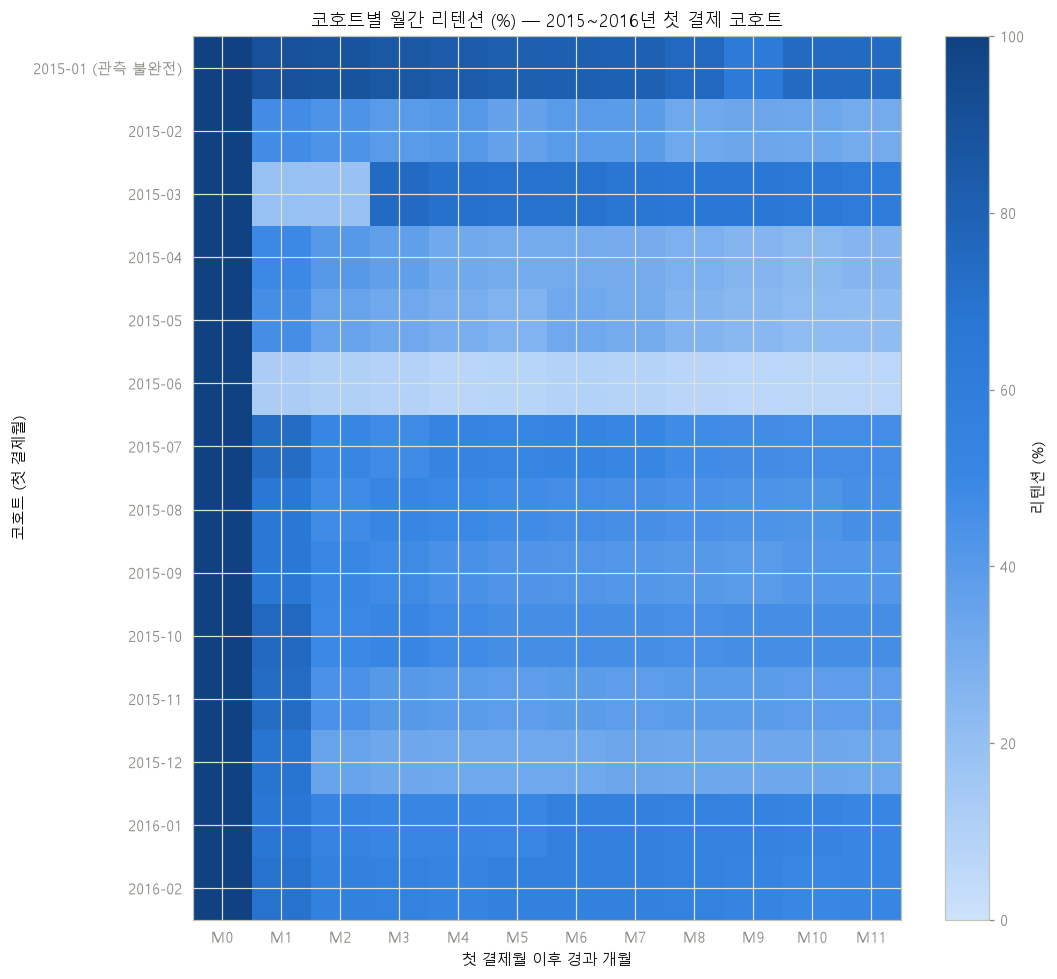

2015-01 코호트 M1 리텐션: 90.0% (다른 코호트는 아래 참고 -- 이질적으로 높다면 left-censoring 의심)
count    13.000000
mean     56.439667
std      20.827415
min      12.336552
25%      46.942326
50%      66.474768
75%      70.266805
max      75.754600
Name: 1, dtype: float64


In [5]:
cohort_sizes = cohort_raw[cohort_raw["month_offset"] == 0].set_index("cohort_month")["active_users"]

pivot = cohort_raw.pivot(index="cohort_month", columns="month_offset", values="active_users")
retention_pct = pivot.div(cohort_sizes, axis=0) * 100

# 12개월 전부 관측 가능한 코호트만 표시 (2016-02 가입까지, 그 이후는 데이터가 2017-02에 끊겨서 관측 기간 부족)
retention_pct = retention_pct[retention_pct.index <= pd.Timestamp("2016-02-01")]
retention_pct.index = retention_pct.index.strftime("%Y-%m")

# 2015-01 코호트는 left-censored: cohort_month = MIN(txn_month)를 데이터 시작월(2015-01)부터만
# 관측할 수 있어서, 실제로는 2015-01 이전부터 활동하던 기존 유저까지 "신규 유입"으로 잘못 집계된다.
# (실제로 이 코호트 M1 리텐션만 90%대로 다른 코호트(12~75%)와 이질적 -- 아래에서 확인)
LEFT_CENSORED_COHORT = "2015-01"
ytick_labels = [f"{c} (관측 불완전)" if c == LEFT_CENSORED_COHORT else c for c in retention_pct.index]

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(retention_pct.values, cmap=BLUE_SEQ_CMAP, aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(retention_pct.columns)))
ax.set_xticklabels([f"M{m}" for m in retention_pct.columns])
ax.set_yticks(range(len(retention_pct.index)))
ax.set_yticklabels(ytick_labels)
ax.set_xlabel("첫 결제월 이후 경과 개월")
ax.set_ylabel("코호트 (첫 결제월)")
ax.set_title("코호트별 월간 리텐션 (%) — 2015~2016년 첫 결제 코호트")
plt.colorbar(im, ax=ax, label="리텐션 (%)")
plt.tight_layout()
plt.show()

print(f"{LEFT_CENSORED_COHORT} 코호트 M1 리텐션: {retention_pct.loc[LEFT_CENSORED_COHORT, 1]:.1f}% "
      f"(다른 코호트는 아래 참고 -- 이질적으로 높다면 left-censoring 의심)")
print(retention_pct[1].drop(index=LEFT_CENSORED_COHORT).describe())

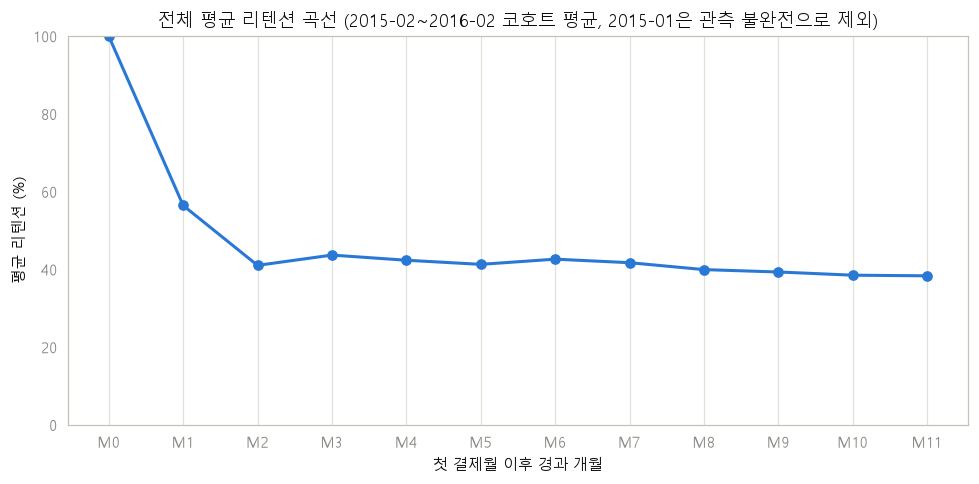

M1(한 달 뒤) 평균 리텐션: 56.4%
M6(반 년 뒤) 평균 리텐션: 42.6%
M11(거의 1년 뒤) 평균 리텐션: 38.3%


In [6]:
# 2015-01 코호트는 left-censored라 평균 계산에서 제외 (위 셀 참고)
avg_retention = retention_pct.drop(index=LEFT_CENSORED_COHORT).mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(avg_retention.index, avg_retention.values, color=SERIES_1, marker="o", linewidth=2)
ax.set_xlabel("첫 결제월 이후 경과 개월")
ax.set_ylabel("평균 리텐션 (%)")
ax.set_title("전체 평균 리텐션 곡선 (2015-02~2016-02 코호트 평균, 2015-01은 관측 불완전으로 제외)")
ax.set_xticks(avg_retention.index)
ax.set_xticklabels([f"M{m}" for m in avg_retention.index])
ax.set_ylim(0, 100)
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"M1(한 달 뒤) 평균 리텐션: {avg_retention[1]:.1f}%")
print(f"M6(반 년 뒤) 평균 리텐션: {avg_retention[6]:.1f}%")
print(f"M11(거의 1년 뒤) 평균 리텐션: {avg_retention[11]:.1f}%")

In [7]:
# ------------------------------------------------------------------
# 해석 시 주의할 점
# 1. "활동 = 해당 월 거래 존재"라는 단순화된 정의를 썼다. 실제 구독 상태(멤버십 유효 기간)를
#    날짜 구간으로 추적하면 리텐션 수치가 달라질 수 있다.
# 2. 2015-01~2017-02 데이터 기반 과거 분석이며, "최근" 트렌드를 나타내지 않는다.
# 3. M1 리텐션이 낮게 보일 수 있는데(30일 주기 구독이 매달 재결제로 잡히므로 정상 패턴에 가까움
#    -- 실제로는 오히려 자동갱신 유저는 매달 거래가 잡히지 않을 수도 있어(자동청구가 갱신일 기준으로만
#    발생) 이 정의 자체의 한계로 리텐션이 과소평가될 수 있음을 감안해야 한다.
# 4. 2015-01 코호트는 left-censored 데이터다: cohort_month은 데이터가 시작하는 2015-01부터만
#    관측 가능해서, 실제로는 그 이전부터 활동하던 기존(이미 정착한) 유저까지 "신규 유입"으로
#    잘못 잡힌다. 그 결과 이 코호트만 리텐션이 이례적으로 높게 나오므로, 히트맵에는 표시하되
#    "관측 불완전"으로 라벨링하고 전체 평균 곡선(M1/M6/M11) 계산에서는 제외했다.
# ------------------------------------------------------------------
print("리텐션/코호트 분석 완료 (위 주석의 해석 주의사항 참고)")

리텐션/코호트 분석 완료 (위 주석의 해석 주의사항 참고)
